# Qwen3.8-27B megakernel vs vLLM DFlash2 on 1x CMP 170HX (SM80, 180 W)

Megakernel authored by **Louis Forster** ([@L-Forster](https://github.com/L-Forster)) in [L-Forster/open-jet `megakernel/`](https://github.com/L-Forster/open-jet/tree/93c2b9abee50ea2ea41981c406cfd201989e4d58/megakernel) @ `93c2b9abee50ea2ea41981c406cfd201989e4d58` (AGPL-3.0). vLLM recipe authored by **syv.ai** ([@syv-ai](https://github.com/syv-ai)).

| Metric (1 card, 180 W, same card, same day) | megakernel MTP d=4 | vLLM DFlash2 k=7 |
|---|---:|---:|
| Decode, c=1, greedy, 5 prompts (mean) | 94.1 tok/s | **181.8 tok/s** |
| Decode, c=1, thinking on, 4 prompts (mean) | 75.6 tok/s | **156.3 tok/s** |
| Prefill, ~3.2K prompt tokens | 1,528 tok/s | **1,915 tok/s** |
| TTFT, short prompt | **0.13 s** | 0.20-0.37 s |

![chart](../assets/charts/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card.png)

```
hf download unsloth/Qwen3.8-27B-GGUF Qwen3.8-27B-Q4_K_M.gguf --revision 4121cb19390a7984a0e6dc0f46bea9177b846f15
```

Evidence: [results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card/](../results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card/README.md) · guide: [docs/models/qwen3.8-27b.md](../docs/models/qwen3.8-27b.md)

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card/.
# LIVE = True is not wired: the live harness is results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card/harness/ (see Reproduce).
import os, sys, json, csv
from pathlib import Path
LIVE = False
REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_DIR = REPO / "results" / "2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card"
sys.path.insert(0, str(RESULTS_DIR))
import summarize
from IPython.display import display, Markdown, Image
def render_table(headers, rows):
    out = "| " + " | ".join(headers) + " |\n|" + "---|" * len(headers) + "\n"
    out += "\n".join("| " + " | ".join(str(c) for c in r) + " |" for r in rows)
    display(Markdown(out))
summary, club, telemetry = summarize.build()
print("LIVE =", LIVE, "| receipts:", RESULTS_DIR.relative_to(REPO), "| summary rows:", len(summary))

LIVE = False | receipts: results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card | summary rows: 52


## 1. TL;DR

**Verdict (measured): no.** On one CMP 170HX the megakernel does **not** beat the club's vLLM + DFlash2 recipe. It is 1.6-2.5x slower in decode on every prompt and 20% slower in prefill. The comparison uses the same card, the same 180 W cap, the same day and the same client.

- The megakernel ports to SM80 with **zero source changes** (`make ARCH=sm_80`). It reports 74 SMs, its output is correct, and decode without speculation is 50.9 tok/s at 180 W.
- Its speedup comes from MTP drafting: at most 4 drafts, so at most 5 tokens per cycle. The DFlash2 k=7 drafter accepts many more tokens per verify pass. CMP's HBM2e makes wide verification cheap, so the bigger draft wins.
- The megakernel wins on start-up (seconds vs 427 s boot for vLLM) and on footprint (16.7 GB of weights on the device).
- The vLLM recipe reproduced its record on this card: decode256 **136.96 tok/s** (record 136.38), prefill 6,603 tok **1,930 tok/s** (record 1,946).
- Two negative results are kept in the appendix. (1) At the 250 W VBIOS default the megakernel hit the 80 °C stop within about a minute. (2) vLLM died with Xid 31 (illegal memory access) on a 9,472-token chat prompt. The megakernel served 9.5K and 19K prompts without error.

In [2]:
pins = [
 ("Hardware", "1x CMP 170HX (GA100, SM80), 64 GiB HBM2e unlocked, 74 SMs, HBM 1,728 MHz, PCIe Gen2 x16, VM passthrough"),
 ("Power / cooling", "nvidia-smi -pl 180 (VBIOS default 250 W); forced chassis airflow, GPU-temperature fan loop"),
 ("Host unlock", "amoghmunikote/cmpunlocker @ 88e39ce (host side); guest driver stock 580.178.04, CUDA 13.0 driver API"),
 ("Container (both arms)", "docker.io/nvidia/cuda@sha256:520292dbb4f755fd360766059e62956e9379485d9e073bbd2f6e3c20c270ed66 (12.8.1-devel-ubuntu24.04)"),
 ("Megakernel source", "L-Forster/open-jet @ 93c2b9abee50ea2ea41981c406cfd201989e4d58, megakernel/ built with make ARCH=sm_80, nvcc 12.8.93"),
 ("Tokenizer library", "ggml-org/llama.cpp b10246 = 39eab74a05d3e68ac822b6dc6cd78c90cb985c19 (libllama, vocab only)"),
 ("Megakernel model", "unsloth/Qwen3.8-27B-GGUF @ 4121cb19390a7984a0e6dc0f46bea9177b846f15, Qwen3.8-27B-Q4_K_M.gguf, sha256 7e78da5d7e3ae28d178121f58646953305f3e5bd3cb46f4a75584e8b6c6fe169 (Apache-2.0)"),
 ("Megakernel serve", "python3 server/mk_server.py -m Qwen3.8-27B-Q4_K_M.gguf --port 18080 -c 65536 -d {4,3,0} (draft vocab draft_vocab_32k.bin, KV auto=f16)"),
 ("vLLM runtime", "syv-ai/qwen38-27b-rtx3090 @ 69ba4d0688c6ae76cb9d3c4a5c3b36445e1b040c, vLLM 0.27.1, torch 2.13.0+cu130, recipes/qwen3.8-27b-dflash2/requirements.lock"),
 ("vLLM model", "dbirks/Qwen3.8-27B-W4A16-AutoRound @ 1f05c441c4e64ae0549de44fa9ea5a6d43610314 + syvai fast overlay @ 124c14e7e8c7d2f5402933b9af368e772a9fcf0c + syvai/Qwen3.8-27B-DFlash2-W4A16 @ 4d30ec736ffc6b8688dc2ae2b502d9b48bdec279"),
 ("vLLM serve", "single-user/start_qwen.sh with SPEC=dflash2 CTX=fast MAX_SEQS=1 DFLASH_TOKENS=7 GPU_UTIL=0.90 (BF16 KV, 65,536 ctx, prefix caching on)"),
 ("Club repo at run time", "PixelML/club-170hx @ 22547592fcfdd7f3804f4387421a631223ac987e"),
]
render_table(["Pin", "Value"], pins)

| Pin | Value |
|---|---|
| Hardware | 1x CMP 170HX (GA100, SM80), 64 GiB HBM2e unlocked, 74 SMs, HBM 1,728 MHz, PCIe Gen2 x16, VM passthrough |
| Power / cooling | nvidia-smi -pl 180 (VBIOS default 250 W); forced chassis airflow, GPU-temperature fan loop |
| Host unlock | amoghmunikote/cmpunlocker @ 88e39ce (host side); guest driver stock 580.178.04, CUDA 13.0 driver API |
| Container (both arms) | docker.io/nvidia/cuda@sha256:520292dbb4f755fd360766059e62956e9379485d9e073bbd2f6e3c20c270ed66 (12.8.1-devel-ubuntu24.04) |
| Megakernel source | L-Forster/open-jet @ 93c2b9abee50ea2ea41981c406cfd201989e4d58, megakernel/ built with make ARCH=sm_80, nvcc 12.8.93 |
| Tokenizer library | ggml-org/llama.cpp b10246 = 39eab74a05d3e68ac822b6dc6cd78c90cb985c19 (libllama, vocab only) |
| Megakernel model | unsloth/Qwen3.8-27B-GGUF @ 4121cb19390a7984a0e6dc0f46bea9177b846f15, Qwen3.8-27B-Q4_K_M.gguf, sha256 7e78da5d7e3ae28d178121f58646953305f3e5bd3cb46f4a75584e8b6c6fe169 (Apache-2.0) |
| Megakernel serve | python3 server/mk_server.py -m Qwen3.8-27B-Q4_K_M.gguf --port 18080 -c 65536 -d {4,3,0} (draft vocab draft_vocab_32k.bin, KV auto=f16) |
| vLLM runtime | syv-ai/qwen38-27b-rtx3090 @ 69ba4d0688c6ae76cb9d3c4a5c3b36445e1b040c, vLLM 0.27.1, torch 2.13.0+cu130, recipes/qwen3.8-27b-dflash2/requirements.lock |
| vLLM model | dbirks/Qwen3.8-27B-W4A16-AutoRound @ 1f05c441c4e64ae0549de44fa9ea5a6d43610314 + syvai fast overlay @ 124c14e7e8c7d2f5402933b9af368e772a9fcf0c + syvai/Qwen3.8-27B-DFlash2-W4A16 @ 4d30ec736ffc6b8688dc2ae2b502d9b48bdec279 |
| vLLM serve | single-user/start_qwen.sh with SPEC=dflash2 CTX=fast MAX_SEQS=1 DFLASH_TOKENS=7 GPU_UTIL=0.90 (BF16 KV, 65,536 ctx, prefix caching on) |
| Club repo at run time | PixelML/club-170hx @ 22547592fcfdd7f3804f4387421a631223ac987e |

## 2. Visible results

All numbers are **measured** at 180 W. Token counts come from the final streamed `usage` object. Decode tok/s = (completion_tokens - 1) / (total - TTFT). Greedy: 3 reps per prompt, max 512 tokens, thinking off. Thinking: 2 seeds per prompt, T=1.0, top_p 0.95, top_k 20, max 1,024 tokens. Both engines get identical chat messages through `/v1/chat/completions` from one client (`harness/chat_bench.py`). The two arms use different 4-bit formats of the same base model (GGUF Q4_K_M vs W4A16 AutoRound), so their outputs differ slightly.

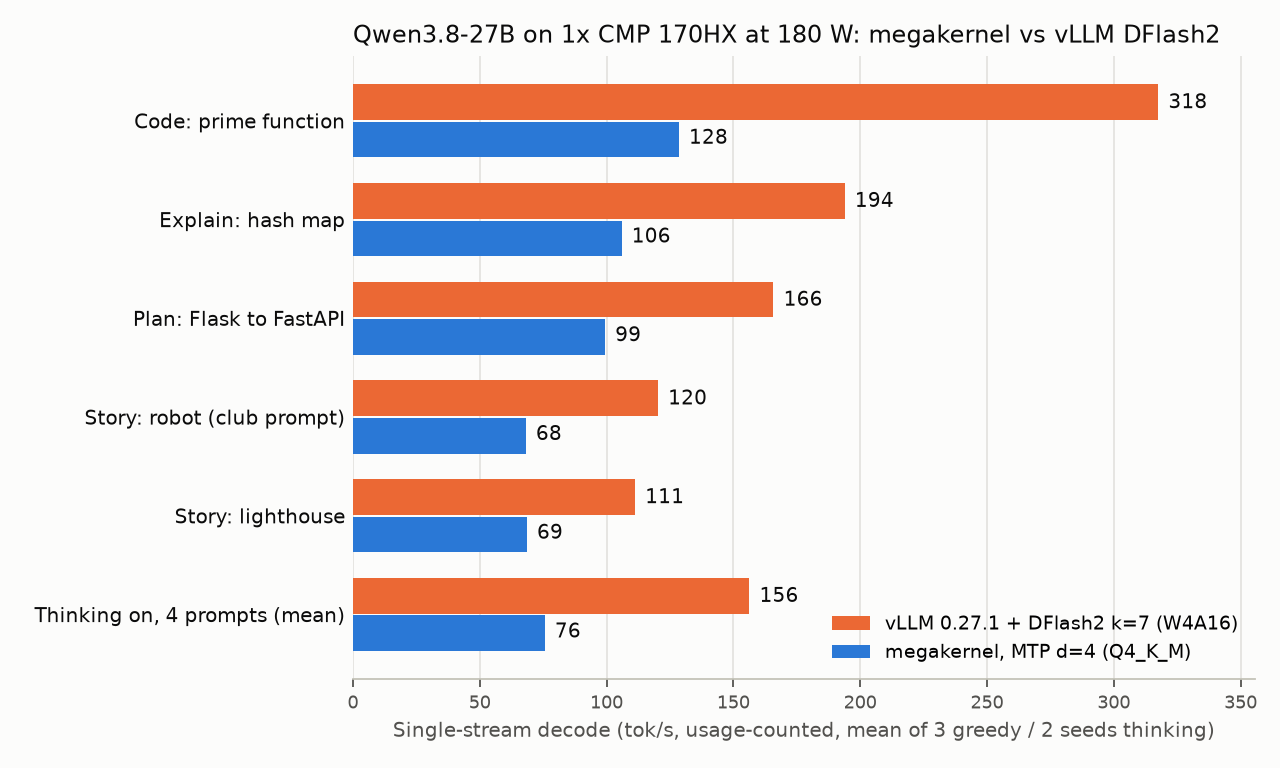

In [3]:
display(Image(filename=str(REPO / "assets/charts/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card.png")))

In [4]:
S = {(r["engine"], r["suite"], r["case"]): r for r in summary if r["cap_w"] == 180}
cases = [("greedy", c) for c in ["code_prime", "hashmap", "flask_fastapi", "story_robot", "story_lighthouse"]] + \
        [("think", c) for c in ["intervals", "bash_largest", "c_ringbuf", "mutex_sem"]]
rows = []
for suite, case in cases:
    g = lambda e: S[(e, suite, case)]["decode_tok_s_mean"]
    v, m4 = g("vllm-dflash2-k7"), g("mk-d4")
    rows.append((suite, case, g("mk-d0") if (("mk-d0", suite, case) in S) else "untested", g("mk-d3"), m4, v, f"{v / m4:.2f}x"))
render_table(["Suite", "Prompt", "mk no-spec (tok/s)", "mk d=3 (tok/s)", "mk d=4 (tok/s)", "vLLM DFlash2 k=7 (tok/s)", "vLLM / mk d=4"], rows)
for e in ["mk-d4", "vllm-dflash2-k7"]:
    for suite in ["greedy", "think"]:
        vals = [S[(e, s, c)]["decode_tok_s_mean"] for s, c in cases if s == suite]
        print(f"{e:16s} {suite:6s} mean of prompt means: {sum(vals) / len(vals):.1f} tok/s")

| Suite | Prompt | mk no-spec (tok/s) | mk d=3 (tok/s) | mk d=4 (tok/s) | vLLM DFlash2 k=7 (tok/s) | vLLM / mk d=4 |
|---|---|---|---|---|---|---|
| greedy | code_prime | 51.76 | 123.1 | 128.5 | 317.52 | 2.47x |
| greedy | hashmap | 51.04 | 106.92 | 105.93 | 193.91 | 1.83x |
| greedy | flask_fastapi | 50.58 | 102.01 | 99.41 | 165.82 | 1.67x |
| greedy | story_robot | 50.44 | 68.26 | 68.16 | 120.28 | 1.76x |
| greedy | story_lighthouse | 50.5 | 69.26 | 68.59 | 111.23 | 1.62x |
| think | intervals | untested | 93.69 | 89.01 | 199.95 | 2.25x |
| think | bash_largest | untested | 77.31 | 75.9 | 147.35 | 1.94x |
| think | c_ringbuf | untested | 65.58 | 65.38 | 130.76 | 2.00x |
| think | mutex_sem | untested | 71.86 | 72.24 | 147.2 | 2.04x |

mk-d4            greedy mean of prompt means: 94.1 tok/s
mk-d4            think  mean of prompt means: 75.6 tok/s
vllm-dflash2-k7  greedy mean of prompt means: 181.8 tok/s
vllm-dflash2-k7  think  mean of prompt means: 156.3 tok/s


In [5]:
rows = []
for (e, suite, case), r in sorted(S.items()):
    if suite == "prefill":
        rows.append((e, r["prompt_tokens"], r["n"], r["ttft_s_mean"], r["prefill_tok_s_mean"]))
render_table(["Engine", "Prompt tokens", "Samples", "TTFT (s)", "Prefill = prompt tokens / TTFT (tok/s)"], rows)
print("vLLM prefill rows end at 3,163 tokens: the next case (9,472 tokens) killed the vLLM engine (Xid 31), see Appendix.")

| Engine | Prompt tokens | Samples | TTFT (s) | Prefill = prompt tokens / TTFT (tok/s) |
|---|---|---|---|---|
| mk-d0 | 9472 | 3 | 6.363 | 1488.6 |
| mk-d0 | 18976 | 3 | 13.557 | 1399.7 |
| mk-d0 | 3158 | 3 | 2.061 | 1532.4 |
| mk-d3 | 9472 | 3 | 6.363 | 1488.5 |
| mk-d3 | 18976 | 3 | 13.556 | 1399.9 |
| mk-d3 | 3158 | 3 | 2.063 | 1531.1 |
| mk-d4 | 9472 | 3 | 6.358 | 1489.7 |
| mk-d4 | 18976 | 3 | 13.55 | 1400.4 |
| mk-d4 | 3158 | 3 | 2.066 | 1528.4 |
| vllm-dflash2-k7 | 3163 | 3 | 1.651 | 1915.3 |

vLLM prefill rows end at 3,163 tokens: the next case (9,472 tokens) killed the vLLM engine (Xid 31), see Appendix.


Club recipe suite, unchanged (`recipes/qwen3.8-27b-dflash2/live_benchmark.py`: `/v1/completions`, temperature 0, `ignore_eos`, 1 warm-up + 3 samples). This run was against the vLLM arm only. `mk_server` has no `/v1/completions`, `/tokenize` or `ignore_eos`.

In [6]:
render_table(["Case", "Prompt tokens", "Output tokens", "Decode (tok/s)", "TTFT (ms)", "Prefill (tok/s)", "Record 2026-08-30 (tok/s)"],
    [(r["case"], r["prompt_tokens"], r["mean_completion_tokens"], r["decode_tok_s"], r["mean_ttft_ms"], r["prefill_tok_s"],
      {"decode256": "136.38", "decode900": "122.00", "prefill_long": "1,946 prefill"}[r["case"]]) for r in club])

| Case | Prompt tokens | Output tokens | Decode (tok/s) | TTFT (ms) | Prefill (tok/s) | Record 2026-08-30 (tok/s) |
|---|---|---|---|---|---|---|
| decode256 | 11 | 256.0 | 136.96 | 209.4 | 52.5 | 136.38 |
| decode900 | 11 | 900.0 | 117.92 | 192.7 | 57.1 | 122.00 |
| prefill_long | 6603 | 8.0 | 104.11 | 3421.7 | 1929.8 | 1,946 prefill |

In [7]:
render_table(["Telemetry file", "1 Hz samples", "Peak core (°C)", "Peak memory (°C)", "Peak power (W)", "Mean power, util > 50% (W)"],
    [(t["file"], t["samples"], t["peak_core_c"], t["peak_mem_c"], t["peak_w"], t["mean_busy_w"]) for t in telemetry])
print("Peak power above the 180 W cap = sub-second transients; the busy mean sits at the cap.")

| Telemetry file | 1 Hz samples | Peak core (°C) | Peak memory (°C) | Peak power (W) | Mean power, util > 50% (W) |
|---|---|---|---|---|---|
| telemetry-mk-d0.csv | 233 | 77.0 | 80.0 | 198.73 | 179.7 |
| telemetry-mk-d3.csv | 274 | 77.0 | 78.0 | 220.28 | 179.9 |
| telemetry-mk-d4.csv | 280 | 77.0 | 77.0 | 212.88 | 178.8 |
| telemetry-vllm.csv | 571 | 76.0 | 78.0 | 209.97 | 171.9 |
| 250w/telemetry-mk-d0.csv | 71 | 80.0 | 82.0 | 256.77 | 248.6 |
| 250w/telemetry-mk-d3.csv | 64 | 80.0 | 79.0 | 257.68 | 243.0 |
| 250w/telemetry-mk-d4.csv | 106 | 80.0 | 79.0 | 261.27 | 240.0 |

Peak power above the 180 W cap = sub-second transients; the busy mean sits at the cap.


## 3. Reproduce

**Hardware.** 1x CMP 170HX with 64 GiB unlocked, forced airflow, and a fail-closed temperature guard (80 °C core, 85 °C memory). 8 CPU cores, 28 GiB RAM, 17 GB for the GGUF plus about 40 GB for the vLLM weights. Measured boot: megakernel a few seconds (weights load); vLLM 427 s (CUDA graph capture + DFlash2).

**1. Power cap (host tuning, the only live change):**
```bash
nvidia-smi -pl 180
```

**2. Container and build (megakernel, about 15 min on 8 cores; most of it is llama.cpp's CUDA build, and a CPU-only libllama would also do):**
```bash
docker run --gpus all -it -v <models>:/models docker.io/nvidia/cuda@sha256:520292dbb4f755fd360766059e62956e9379485d9e073bbd2f6e3c20c270ed66 bash
bash results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card/harness/build.sh   # llama.cpp b10246 = 39eab74a05d3e68ac822b6dc6cd78c90cb985c19, open-jet 93c2b9abee50ea2ea41981c406cfd201989e4d58, make ARCH=sm_80
```

**3. Weights:**
```bash
hf download unsloth/Qwen3.8-27B-GGUF Qwen3.8-27B-Q4_K_M.gguf --revision 4121cb19390a7984a0e6dc0f46bea9177b846f15 --local-dir /models/qwen3.8-27b-gguf
sha256sum /models/qwen3.8-27b-gguf/Qwen3.8-27B-Q4_K_M.gguf   # 7e78da5d7e3ae28d178121f58646953305f3e5bd3cb46f4a75584e8b6c6fe169
```
The plain `Qwen3.8-27B-Q4_K_M.gguf` was deleted from the repo's `main` on 2026-08-19 (commit `e1d8a26782d4ce57b3c612e29a58cfb8f491c2fc`). The megakernel loader accepts only this quant mix, so pin the revision above.

**4. Serve and benchmark the megakernel:**
```bash
python3 /work/open-jet/megakernel/server/mk_server.py -m /models/qwen3.8-27b-gguf/Qwen3.8-27B-Q4_K_M.gguf --port 18080 -c 65536 -d 4 &
python3 results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card/harness/chat_bench.py --url http://127.0.0.1:18080 --engine mk-d4 --out mk.jsonl \
   --suites greedy,think,prefill --long-file /work/open-jet/megakernel/prefill.cuh --long-chars 8000,24000,48000
```
`harness/run_mk.sh` runs d=4, 3 and 0 in sequence with the guard (`harness/guard.sh`).

**5. vLLM control:** follow `recipes/qwen3.8-27b-dflash2/reproduce.ipynb`. In a fresh environment its install step currently fails (see Appendix), so use `harness/install_vllm.sh` followed by the manual fix listed there. `harness/run_vllm.sh` then runs the unchanged club suite and the same chat suite.

**6. Try your own prompt** (megakernel server; edit the content):

In [8]:
PROMPT = "Write a Python function that merges overlapping intervals, with two pytest tests."
request = {"model": "qwen3.8-27b", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 512,
           "temperature": 0.0, "chat_template_kwargs": {"enable_thinking": False}}
print("curl -s http://127.0.0.1:18080/v1/chat/completions -H 'Content-Type: application/json' -d '" + json.dumps(request) + "'")
if LIVE:
    import urllib.request
    url = os.environ["MK_URL"].rstrip("/") + "/v1/chat/completions"
    r = json.load(urllib.request.urlopen(urllib.request.Request(url, json.dumps(request).encode(), {"Content-Type": "application/json"})))
    print(r["choices"][0]["message"]["content"][:1500]); print(r["usage"])
else:
    rec = [json.loads(l) for l in (RESULTS_DIR / "receipts/180w/mk.jsonl").read_text().splitlines()]
    first = next(r for r in rec if r["engine"] == "mk-d4" and r["case"] == "code_prime")
    print("Recorded megakernel reply (first 400 chars, code_prime, d=4):\n" + first["text_head"])

curl -s http://127.0.0.1:18080/v1/chat/completions -H 'Content-Type: application/json' -d '{"model": "qwen3.8-27b", "messages": [{"role": "user", "content": "Write a Python function that merges overlapping intervals, with two pytest tests."}], "max_tokens": 512, "temperature": 0.0, "chat_template_kwargs": {"enable_thinking": false}}'
Recorded megakernel reply (first 400 chars, code_prime, d=4):
```python
def is_prime(n: int) -> bool:
    """Check whether a given integer is a prime number.

    A prime number is a natural number greater than 1 that has no positive
    divisors other than 1 and itself.

    Args:
        n: The integer to check for primality.

    Returns:
        True if n is a prime number, False otherwise.

    Examples:
        >>> is_prime(2)
        True
        >>> 


## 4. Appendix

<details><summary><b>Failures, fixes and dead ends</b> (click to open)</summary>

1. **Thermal stop at the 250 W VBIOS default (measured).** The megakernel ran at a mean of 240-249 W, which is the cap. It reached 80 °C core within about a minute, and the guard stopped it repeatedly. The greedy receipts that finished before a stop are kept in `receipts/250w-thermal-stop/` (d=4: code 137.0, hashmap 114.7, story 75.7 tok/s; d=0: 56.2). The think and prefill suites did not finish. Fix: `nvidia-smi -pl 180`. Cost of the cap: -6 to -10% decode for the megakernel (code 137.0 → 128.5).
2. **vLLM Xid 31 on a 9,472-token chat prompt (measured, cause not identified).** `CUDA error: an illegal memory access`. The guest kernel log shows `Xid 31 ... MMU Fault: ENGINE GRAPHICS GPC0 ... FAULT_PDE ACCESS_TYPE_VIRT_READ` from the vLLM EngineCore, and the engine died. The card stayed healthy (0 MiB used, 57 °C afterwards). The club suite's 6,603-token `/v1/completions` prompt and the 3,163-token chat prompt passed. This is not the cmpunlocker WPR `REGION_VIOLATION` bug from the MiMo notebook (different fault type; stock guest driver). All GPU load stopped after the Xid, per AGENTS.md. The vLLM prefill rows at 9.5K/19K are therefore **untested**.
3. **Recipe install fails in a fresh environment (measured).** `requirements.lock` does not pin `nvidia-cuda-nvcc`. Version 13.4.92 installs under `nvidia/cu13/`, so the recipe's `import nvidia.cuda_nvcc` step raises `ModuleNotFoundError`. Manual fix: link `site-packages/nvidia/cu13/bin/nvcc` to `/usr/local/cuda/bin/nvcc` and `nvidia/cu13/include/curand.h` to `/usr/local/cuda/include/`, then apply `patches/*.patch` (all applied cleanly). The recipe's final check `grep dflash2-backport "$SP/vllm/engine/arg_utils.py"` looks in a path that does not exist. DFlash2 still loaded: the server log shows "Capturing model for DFlash2 speculator".
4. **flashinfer top-k JIT fell back to `torch.topk` (measured).** The container's CUDA 12.8 headers do not match the cu13 nvcc ("CUDA compiler and CUDA toolkit headers are incompatible"). The decode256 result still matched the record (136.96 vs 136.38), so this run did not measure a cost.
5. **llama.cpp baseline dropped.** The upstream README compares against llama-server. The club's baseline for this model is vLLM DFlash2, so llama.cpp served only as the megakernel's tokenizer library.

</details>

<details><summary><b>Method notes and limitations</b></summary>

- One card, one day, one run per configuration (3 reps greedy, 2 seeds thinking). Card-to-card spread is not measured here.
- The two arms use different 4-bit checkpoints of the same model: GGUF Q4_K_M (unsloth) vs W4A16 AutoRound (dbirks) plus the syvai int8 lm_head overlay. Output lengths differ per prompt; the decode metric is per generated token.
- Streaming decode for DFlash2 sends multi-token chunks, so the first chunk can hold several tokens. Over 256-1,024 tokens this changes the metric by less than about 1% (inferred).
- vLLM prefix caching was on (recipe default). Every prefill prompt starts with a unique first line, so no cached prefix was reused.
- Megakernel prefill is batched tensor-core GEMMs from the k-quants. It measured 1,400-1,532 tok/s from 3.2K to 19K tokens with no errors.
- Not tested: concurrency (the megakernel serves one sequence at a time), contexts above 19K, the q8 KV path.
- Evidence: `results/2026-10-10-qwen3.8-27b-megakernel-vs-dflash2-1card/` (receipts, telemetry, harness, summary.csv). Upstream: [L-Forster/open-jet](https://github.com/L-Forster/open-jet), RTX 3090 reference numbers in its `megakernel/README.md` (**community-reported**: 3090 d=4 code 139.7 tok/s; on CMP at 250 W we measured 137.0 on the same prompt).

</details>